# Named Entity Extractor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/ner-extractor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/ner-extractor/demo.ipynb)

> "Pull the names, orgs, money, and dates out of this text" — structured entities, no heavy model download.

So much value is trapped in prose: who, which company, how much, when. Named entity recognition pulls
those out as structured fields. This build gets you there with **zero dependencies** - regex +
capitalization rules that are precise on structured entities - and upgrades to Claude for higher
recall when a key is present.

**What this notebook covers**
1. Rule-based extraction of MONEY, DATE, EMAIL, PERCENT
2. ORG detection via legal suffixes (Inc, LLC, Corp...)
3. A capitalization heuristic for PERSON
4. Grouping entities by type
5. Entity counts, visualized


## Step 1 - Structured entities are easy and precise

Money, dates, emails, and percentages have regular shapes - regex nails them with near-perfect
precision. No model needed.

In [1]:
from ner import extract_entities, group_by_label, heuristic_ner, SAMPLE_TEXT

print(SAMPLE_TEXT)
print()
for e in heuristic_ner(SAMPLE_TEXT):
    if e.label in ("MONEY", "DATE", "EMAIL", "PERCENT"):
        print(f"  {e.label:<8} {e.text}")


On March 15, 2026, Acme Analytics Inc. announced that Sarah Chen would join as CTO. The company raised $12 million in a round led by Beta Ventures LLC, a 40% increase over its previous valuation. Questions can be sent to press@acme.com. Michael Torres, formerly of Globex Corporation, will lead the new AI Labs division.

  DATE     March 15, 2026
  MONEY    $12 million
  PERCENT  40%
  EMAIL    press@acme.com


## Step 2 - Organizations via legal suffixes

Company names are hard in general, but a huge fraction end in a tell: Inc, LLC, Corp, Ltd, Group,
Labs, University. Matching the capitalized run *before* that suffix catches most orgs cheaply.

In [2]:
for e in heuristic_ner(SAMPLE_TEXT):
    if e.label == "ORG":
        print(f"  ORG   {e.text}")


  ORG   Acme Analytics Inc
  ORG   Beta Ventures LLC
  ORG   Globex Corporation
  ORG   AI Labs


## Step 3 - People (the fuzzy one) + the full picture

PERSON is the hardest without a model: we take capitalized multi-word sequences that aren't already
another entity and don't start with a stopword. Not perfect - but combined with the precise rules, it
covers the common cases.

In [3]:
ents = extract_entities(SAMPLE_TEXT)
for e in ents:
    print(f"  {e.label:<8} {e.text}")


  DATE     March 15, 2026
  ORG      Acme Analytics Inc
  PERSON   Sarah Chen
  MONEY    $12 million
  ORG      Beta Ventures LLC
  PERCENT  40%
  EMAIL    press@acme.com
  PERSON   Michael Torres
  ORG      Globex Corporation
  ORG      AI Labs


## Step 4 - Group by type

The usable output: entities collapsed into typed lists, ready to write to columns, a graph, or a
search index.

In [4]:
import json
print(json.dumps(group_by_label(ents), indent=2))


{
  "DATE": [
    "March 15, 2026"
  ],
  "ORG": [
    "Acme Analytics Inc",
    "Beta Ventures LLC",
    "Globex Corporation",
    "AI Labs"
  ],
  "PERSON": [
    "Sarah Chen",
    "Michael Torres"
  ],
  "MONEY": [
    "$12 million"
  ],
  "PERCENT": [
    "40%"
  ],
  "EMAIL": [
    "press@acme.com"
  ]
}


## Step 5 - Entity mix, visualized

A quick profile of what kind of information this text carries.

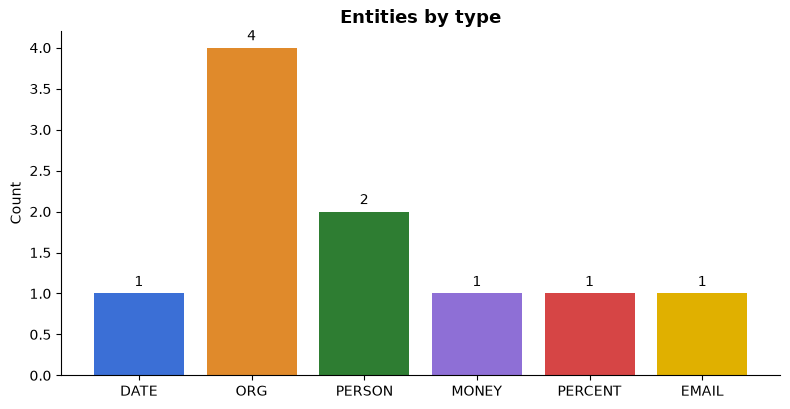

In [5]:
import matplotlib.pyplot as plt

grouped = group_by_label(ents)
labels = list(grouped)
counts = [len(grouped[k]) for k in labels]
colors = ["#3b6fd6", "#e08a2b", "#2e7d32", "#8e6fd6", "#d64545", "#e0b000", "#3aa6a6"]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(labels, counts, color=colors[:len(labels)])
ax.set_title("Entities by type", fontsize=13, weight="bold")
ax.set_ylabel("Count")
ax.bar_label(bars, padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("entity_counts.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Type | How | Precision |
|------|-----|-----------|
| MONEY / DATE / EMAIL / PERCENT | regex | high |
| ORG | capitalized run + legal suffix | high |
| PERSON | capitalized sequence heuristic | medium |

The rule-based extractor is fast, free, and offline - great for structured entities and a solid
first pass on names/orgs. Set `ANTHROPIC_API_KEY` and it swaps to Claude for higher recall
(locations, roles, orgs without a suffix).

**Extend it:** add a gazetteer for locations, resolve coreferences ("the company" → Acme), and link
entities to a knowledge base.

In [6]:
# --- Try your own text ---
# text = "Paste any article, email, or report here..."
# for e in extract_entities(text):
#     print(e.label, e.text)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 115,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`